1. ПРОВЕРКА ВЕРСИЙ
Python: 3.14.0b3 (tags/v3.14.0b3:26d485d, Jun 17 2025, 16:21:24) [MSC v.1943 64 bit (AMD64)]
NumPy: 2.4.2
Pandas: 3.0.1
Scikit-learn: 1.8.0

2. ЗАДАНИЯ ПО NUMPY

Создана матрица X размера: (100, 5)

Статистика всей матрицы:
Среднее (mean): 0.0068
Стандартное отклонение (std): 0.9803
Минимум (min): -3.2413
Максимум (max): 3.8527

Статистика по каждому столбцу (axis=0):
Средние: [-0.04474719  0.07695423 -0.09387351  0.12805847 -0.03220203]
Стандартные отклонения: [0.89583921 0.9791772  0.97901142 0.95474576 1.06742857]
Минимумы: [-1.9520878  -2.30192116 -3.24126734 -1.91328024 -2.6197451 ]
Максимумы: [2.31465857 1.8861859  2.1221562  3.07888081 3.85273149]

Векторизация y = X @ w:
Размерность y: (100,)
Первые 5 значений y: [  7.08460372   6.06149554 -16.94670053 -12.33882258  -7.20422559]

3. ЗАДАНИЯ ПО PANDAS

Первые 5 строк DataFrame (head()):
   feature_1  feature_2  feature_3  feature_4  feature_5     target
0   0.496714  -0.138264   0.647689   1.523030  -0.234153 

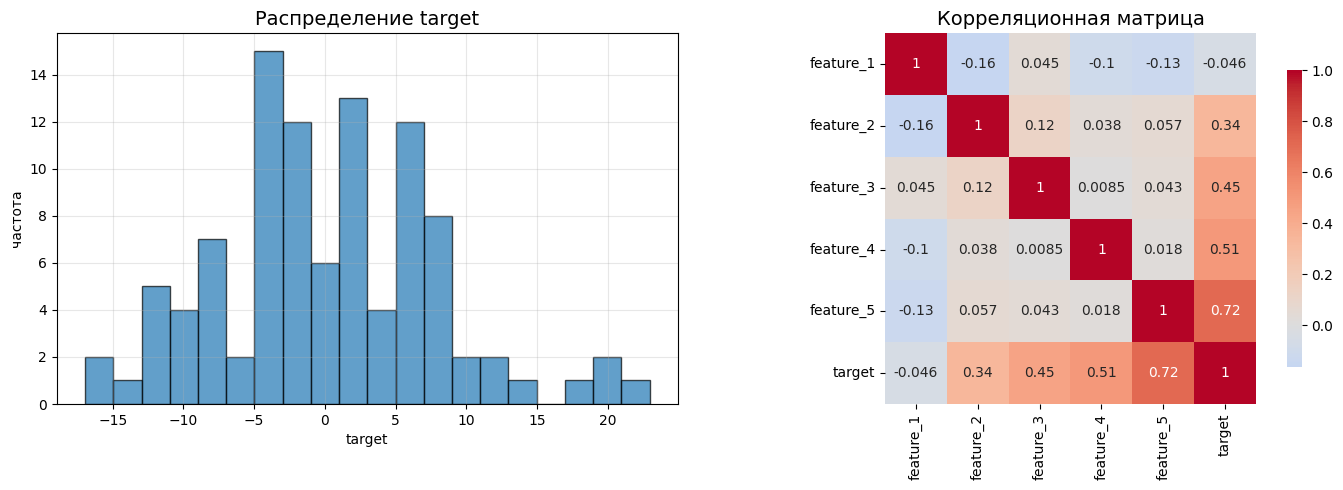


5. БОНУС: ДАТАСЕТ IRIS


In [ ]:
# HW01 - Настройка окружения
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 50)
print("1. ПРОВЕРКА ВЕРСИЙ")
print("=" * 50)
print(f"Python: {sys.version}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")

print("\n" + "=" * 50)
print("2. ЗАДАНИЯ ПО NUMPY")
print("=" * 50)

# Фиксируем seed для воспроизводимости
np.random.seed(42)

# Создаем матрицу 100x5
X = np.random.randn(100, 5)
print(f"\nСоздана матрица X размера: {X.shape}")

# Статистика всей матрицы
print("\nСтатистика всей матрицы:")
print(f"Среднее (mean): {np.mean(X):.4f}")
print(f"Стандартное отклонение (std): {np.std(X):.4f}")
print(f"Минимум (min): {np.min(X):.4f}")
print(f"Максимум (max): {np.max(X):.4f}")

# Статистика по столбцам
print("\nСтатистика по каждому столбцу (axis=0):")
print(f"Средние: {np.mean(X, axis=0)}")
print(f"Стандартные отклонения: {np.std(X, axis=0)}")
print(f"Минимумы: {np.min(X, axis=0)}")
print(f"Максимумы: {np.max(X, axis=0)}")

# Векторизация
w = np.array([1, 2, 3, 4, 5])
y = X @ w
print(f"\nВекторизация y = X @ w:")
print(f"Размерность y: {y.shape}")
print(f"Первые 5 значений y: {y[:5]}")

print("\n" + "=" * 50)
print("3. ЗАДАНИЯ ПО PANDAS")
print("=" * 50)

# Создаем DataFrame
columns = ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']
df = pd.DataFrame(X, columns=columns)
df['target'] = y

print("\nПервые 5 строк DataFrame (head()):")
print(df.head())

print(f"\nРазмерность DataFrame (shape): {df.shape}")

print("\nСтатистическое описание (describe()):")
print(df.describe())

print("\nПроверка пропусков (isnull().sum()):")
print(df.isnull().sum())

print("\nФильтрация данных (target > 0):")
df_filtered = df[df['target'] > 0]
print(f"Всего строк: {len(df)}, после фильтрации: {len(df_filtered)}")

print("\n" + "=" * 50)
print("4. ВИЗУАЛИЗАЦИЯ")
print("=" * 50)

# Создаем графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма target
axes[0].hist(df['target'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение target', fontsize=14)
axes[0].set_xlabel('target')
axes[0].set_ylabel('частота')
axes[0].grid(True, alpha=0.3)

# Тепловая карта корреляций
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, 
            square=True, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title('Корреляционная матрица', fontsize=14)

plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("5. БОНУС: ДАТАСЕТ IRIS")
print("=" * 50)

try:
    from sklearn.datasets import load_iris
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import accuracy_score
    
    # Загружаем данные
    iris = load_iris()
    X_iris, y_iris = iris.data, iris.target
    
    # Создаем DataFrame
    df_iris = pd.DataFrame(X_iris, columns=iris.feature_names)
    df_iris['species'] = y_iris
    
    print(f"\nДанные Iris загружены:")
    print(f"Размерность: {df_iris.shape}")
    print(f"Признаки: {iris.feature_names}")
    print(f"Целевые классы: {iris.target_names}")
    
    # Разделяем на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(
        X_iris, y_iris, test_size=0.3, random_state=42
    )
    
    # Обучаем модель
    model = LogisticRegression(max_iter=200)
    model.fit(X_train, y_train)
    
    # Предсказание и оценка
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\nМодель LogisticRegression:")
    print(f"Точность (accuracy): {accuracy:.4f} ({accuracy*100:.2f}%)")
    
except Exception as e:
    print(f"Ошибка при выполнении бонусной части: {e}")

print("\n" + "=" * 50)
print("ЗАДАНИЕ ВЫПОЛНЕНО УСПЕШНО! 🎉")
print("=" * 50)